<a href="https://colab.research.google.com/github/AndrewLoweUoM/NFM/blob/main/Hydro_Analysis_(Part_1)_Flow_%26_Rainfall_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code - Flow and Rainfall Analysis

This script performs hydrological analysis on hourly and daily flow–rainfall data (all, before and after data), including:

* Data cleaning and visualisation
* Flow Duration Curve (FDC) analysis
* Rainfall–flow relationship analysis
* Trend detection using Mann-Kendall test and Sen’s slope


## Hydrology Analysis of Hourly Data

### Load Hourly Data and Create DataFrame ``` df_hourly ```



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np

# Load all hourly data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_hourly.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly.csv'
# Load hourly data before NFM
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_before.csv'
# Load all hourly data after NFM
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_after.csv'
df_hourly = pd.read_csv(file_path)

# Convert Date column to datetime objects using explicit format
df_hourly['Date'] = pd.to_datetime(df_hourly['Date'], format='%Y-%m-%d %H:%M:%S')

# Set Date as the index for the DataFrame
df_hourly.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print(df_hourly.head())

                     Flow_m3s  Rain_mm
Date                                  
2021-01-29 00:00:00  24.59700    4.063
2021-01-29 01:00:00  24.14200    4.025
2021-01-29 02:00:00  23.85675    4.001
2021-01-29 03:00:00  23.64425    3.983
2021-01-29 04:00:00  23.70300    3.988


### Check Missing Values and Describe Statistics in ``` df_hourly ```

In [4]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df_hourly.shape)

Shape of data: (42728, 2)


In [5]:
# Check for missing values in the DataFrame
print(df_hourly.isnull().sum())

# Replace null values with 0
#df_hourly.fillna(0, inplace=True)
#df_hourly.fillna(method='ffill', inplace=True)

Flow_m3s    0
Rain_mm     0
dtype: int64


In [6]:
# Describe statistics of DataFrame
df_hourly.describe()

,Flow_m3s,Rain_mm
count,42728.000000,42728.000000
mean,4.411316,1.616577
std,4.397180,0.638649
min,0.660000,0.503000
25%,1.947000,1.178000
50%,2.888500,1.418000
75%,5.122750,1.867000
max,52.651250,5.973000


## Data Visualisation (Hourly)

### Plot Rainfall and Flow Timeseries (Hourly)

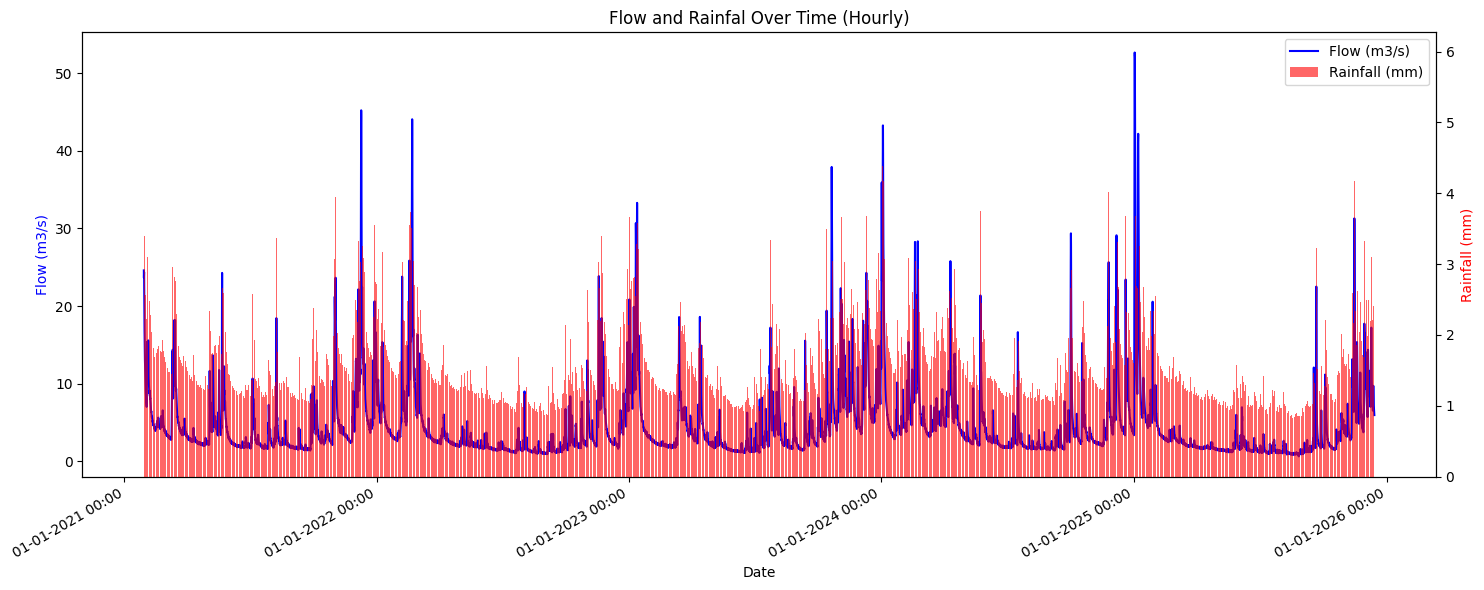

In [7]:
# Create a figure and a set of subplots for hourly data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_hourly.index, df_hourly['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
# Using pd.Timedelta(hours=0.8) for better alignment in hourly frequency
bars1 = ax2.bar(df_hourly.index, df_hourly['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(hours=0.8))

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfal Over Time (Hourly)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

## Flow Duration Curves (FDC) Analysis (Hourly)

Key steps Steps:
* Extract and clean flow values
* Sort in descending order
* Compute exceedance probability:

Calculate key hydrological metrics:
* Mean flow
* Median flow
* Q5 (high flow) → 95th percentile
* Q95 (low flow) → 5th percentile
* Q5/Q95 ratio (flow variability indicator)
* R2FDC slope (flow regime indicator)

Plot:
* Log-scale flow vs exceedance probability
* Highlight Q5 and Q95
* Output summary table

### Flow Duration Curve (Hourly Data)


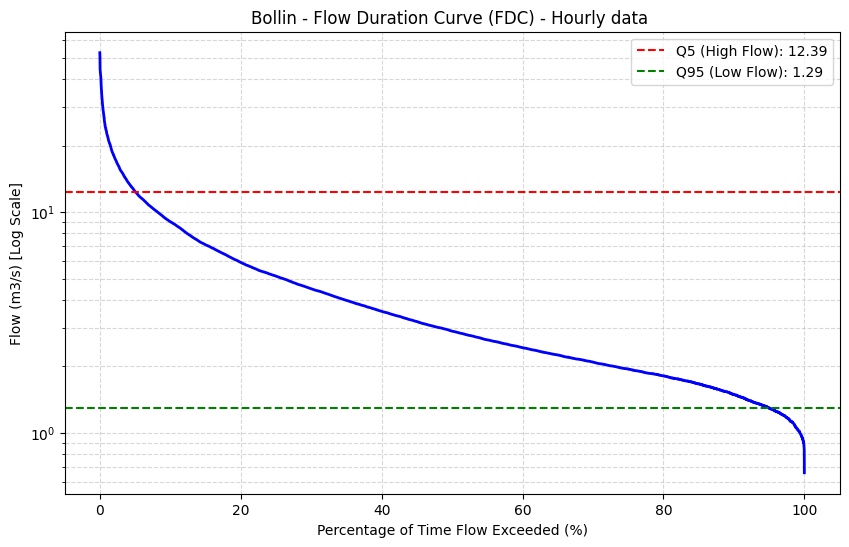

,Metric,Value
0,Mean Flow,4.411
1,Median Flow,2.888
2,Q5 (5% Exceedance),12.386
3,Q95 (95% Exceedance),1.294
4,Q5:Q95 Ratio,9.576
5,R2FDC (Slope),0.904


In [8]:
import pandas as pd

# Prepare combined flow data
all_flow_values = df_hourly['Flow_m3s'].dropna().values
all_flow_sorted = np.sort(all_flow_values)[::-1]

# Calculate exceedance probability (P = m / (n + 1))
exceedance = np.arange(1, len(all_flow_sorted) + 1) / (len(all_flow_sorted) + 1) * 100

# Calculate Metrics
mean_flow = np.mean(all_flow_values)
median_flow = np.median(all_flow_values)
q5 = np.percentile(all_flow_values, 95)  # 5% exceedance is 95th percentile
q95 = np.percentile(all_flow_values, 5)   # 95% exceedance is 5th percentile
q5_q95_ratio = q5 / q95 if q95 != 0 else np.nan

# R2FDC Calculation (Slope between 20th and 70th percentile flows)
# Formula: (log(Q20) - log(Q70)) / (0.70 - 0.20)
q20 = np.percentile(all_flow_values, 80)
q70 = np.percentile(all_flow_values, 30)
r2fdc = (np.log10(q20) - np.log10(q70)) / (0.70 - 0.20)

# Create the FDC Plot
plt.figure(figsize=(10, 6))
plt.plot(exceedance, all_flow_sorted, color='blue', linewidth=2)
plt.yscale('log')
plt.xlabel('Percentage of Time Flow Exceeded (%)')
plt.ylabel('Flow (m3/s) [Log Scale]')
plt.title('Bollin - Flow Duration Curve (FDC) - Hourly data ')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Add horizontal lines for Q5 and Q95
plt.axhline(q5, color='red', linestyle='--', label=f'Q5 (High Flow): {q5:.2f}')
plt.axhline(q95, color='green', linestyle='--', label=f'Q95 (Low Flow): {q95:.2f}')
plt.legend()

plt.show()

# 5. Output Summary Table
fdc_metrics = pd.DataFrame({
    'Metric': ['Mean Flow', 'Median Flow', 'Q5 (5% Exceedance)', 'Q95 (95% Exceedance)', 'Q5:Q95 Ratio', 'R2FDC (Slope)'],
    'Value': [mean_flow, median_flow, q5, q95, q5_q95_ratio, r2fdc]
})

display(fdc_metrics.round(3))

Interpretation Value:
* Q5 → flood/high-flow conditions
* Q95 → drought/baseflow conditions
* Q5/Q95 ratio → flashy vs stable catchment
* R2FDC slope → responsiveness of catchment

## Hydrology Analysis of Daily Data

### Load Daily Data and Create DataFrame ``` df_daily ```



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np

# Load all daily data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_daily.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily.csv'
# Load all daily data before NFM
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_before.csv'
# Load all daily data after NFM
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_after.csv'
df_daily = pd.read_csv(file_path)

# Convert Date column to datetime objects using explicit format
df_daily['Date'] = pd.to_datetime(df_daily['Date'], format='%Y-%m-%d')

# Set Date as the index for the DataFrame
df_daily.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print(df_daily.head())

             Flow_m3s  Rain_mm
Date                          
2021-01-29  21.860875   91.741
2021-01-30  13.824458   72.950
2021-01-31   9.744073   61.351
2021-02-01   7.818292   55.069
2021-02-02  11.542990   66.109


### Check Missing Values and Describe Statistics in ``` df_daily ```

In [10]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df_daily.shape)

Shape of data: (1781, 2)


In [11]:
# Check for missing values in the DataFrame
print(df_daily.isnull().sum())

# Replace null values with 0
#df_daily.fillna(0, inplace=True)
#df_daily.fillna(method='ffill', inplace=True)

Flow_m3s    0
Rain_mm     0
dtype: int64


In [12]:
# Describe statistics of DataFrame
df_daily.describe()

,Flow_m3s,Rain_mm
count,1781.000000,1781.000000
mean,4.411987,38.783322
std,4.234117,14.948815
min,0.909771,14.845000
25%,1.957125,28.266000
50%,2.919365,34.122000
75%,5.141312,44.710000
max,43.953021,129.826000


## Visualuse Data (Daily)

### Plot Rainfall and Flow Timeseries (Daily)

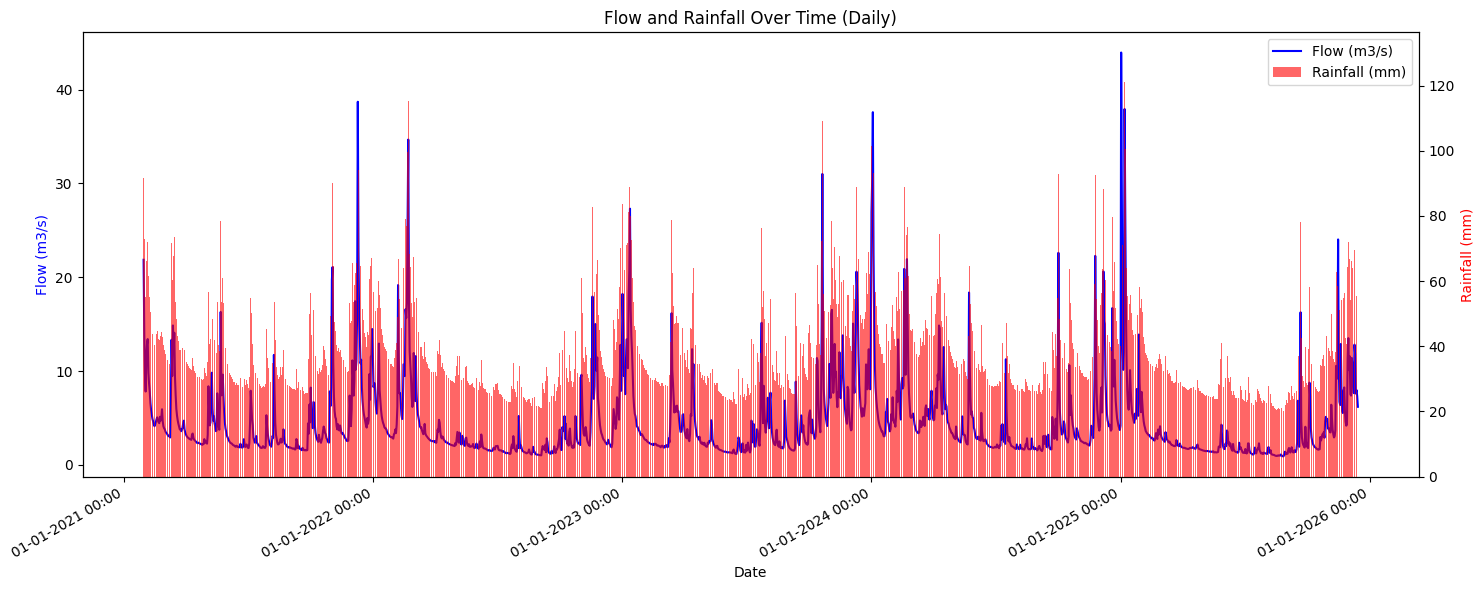

In [13]:
# Create a figure and a set of subplots for daily data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_daily.index, df_daily['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
bars1 = ax2.bar(df_daily.index, df_daily['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=0.8)

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfall Over Time (Daily)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

## Flow Duration Curve (FDC) Analysis (Daily)

### Flow Duration Curve (Daily Data)


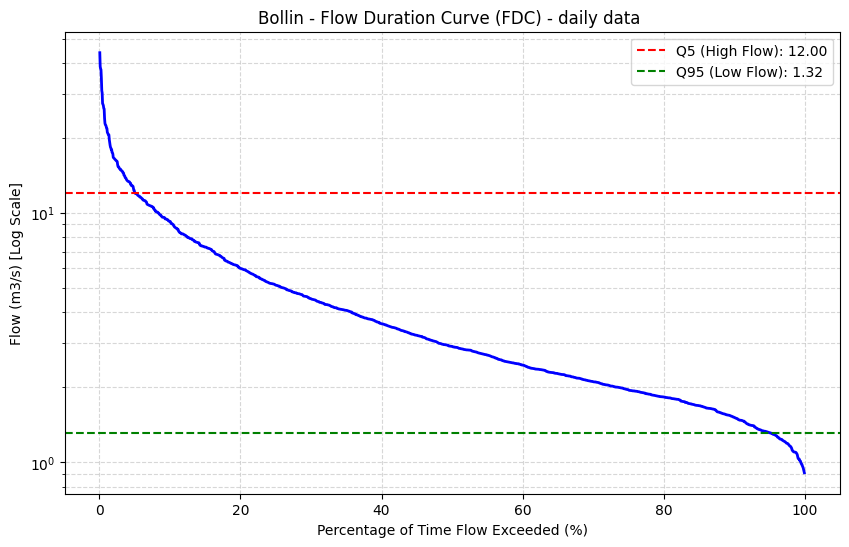

,Metric,Value
0,Mean Flow,4.412
1,Median Flow,2.919
2,Q5 (5% Exceedance),12.004
3,Q95 (95% Exceedance),1.318
4,Q5:Q95 Ratio,9.104
5,R2FDC (Slope),0.909


In [14]:
import pandas as pd

# Prepare combined flow data
all_flow_values = df_daily['Flow_m3s'].dropna().values
all_flow_sorted = np.sort(all_flow_values)[::-1]

# Calculate exceedance probability (P = m / (n + 1))
exceedance = np.arange(1, len(all_flow_sorted) + 1) / (len(all_flow_sorted) + 1) * 100

# Calculate Metrics
mean_flow = np.mean(all_flow_values)
median_flow = np.median(all_flow_values)
q5 = np.percentile(all_flow_values, 95)  # 5% exceedance is 95th percentile
q95 = np.percentile(all_flow_values, 5)   # 95% exceedance is 5th percentile
q5_q95_ratio = q5 / q95 if q95 != 0 else np.nan

# R2FDC Calculation (Slope between 20th and 70th percentile flows)
# Formula: (log(Q20) - log(Q70)) / (0.70 - 0.20)
q20 = np.percentile(all_flow_values, 80)
q70 = np.percentile(all_flow_values, 30)
r2fdc = (np.log10(q20) - np.log10(q70)) / (0.70 - 0.20)

# Create the FDC Plot
plt.figure(figsize=(10, 6))
plt.plot(exceedance, all_flow_sorted, color='blue', linewidth=2)
plt.yscale('log')
plt.xlabel('Percentage of Time Flow Exceeded (%)')
plt.ylabel('Flow (m3/s) [Log Scale]')
plt.title('Bollin - Flow Duration Curve (FDC) - daily data ')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Add horizontal lines for Q5 and Q95
plt.axhline(q5, color='red', linestyle='--', label=f'Q5 (High Flow): {q5:.2f}')
plt.axhline(q95, color='green', linestyle='--', label=f'Q95 (Low Flow): {q95:.2f}')
plt.legend()

plt.show()

# 5. Output Summary Table
fdc_metrics = pd.DataFrame({
    'Metric': ['Mean Flow', 'Median Flow', 'Q5 (5% Exceedance)', 'Q95 (95% Exceedance)', 'Q5:Q95 Ratio', 'R2FDC (Slope)'],
    'Value': [mean_flow, median_flow, q5, q95, q5_q95_ratio, r2fdc]
})

display(fdc_metrics.round(3))

Interpretation Value:
* Q5 → flood/high-flow conditions
* Q95 → drought/baseflow conditions
* Q5/Q95 ratio → flashy vs stable catchment
* R2FDC slope → responsiveness of catchment

## Rainfall–Flow Relationship

Quantify rainfall–runoff relationship:

* Statistical Analysis:

  * Pearson correlation

* Visualisation:
  * Scatter plot with regression line (seaborn.regplot)
  * Displays:
    * Correlation coefficient (r)
    * p-value (significance)

### Scatter Plot of Rainfall verses Flow (Daily Data)


Pearson Correlation Coefficient: 0.9689
P-value: 0.0000


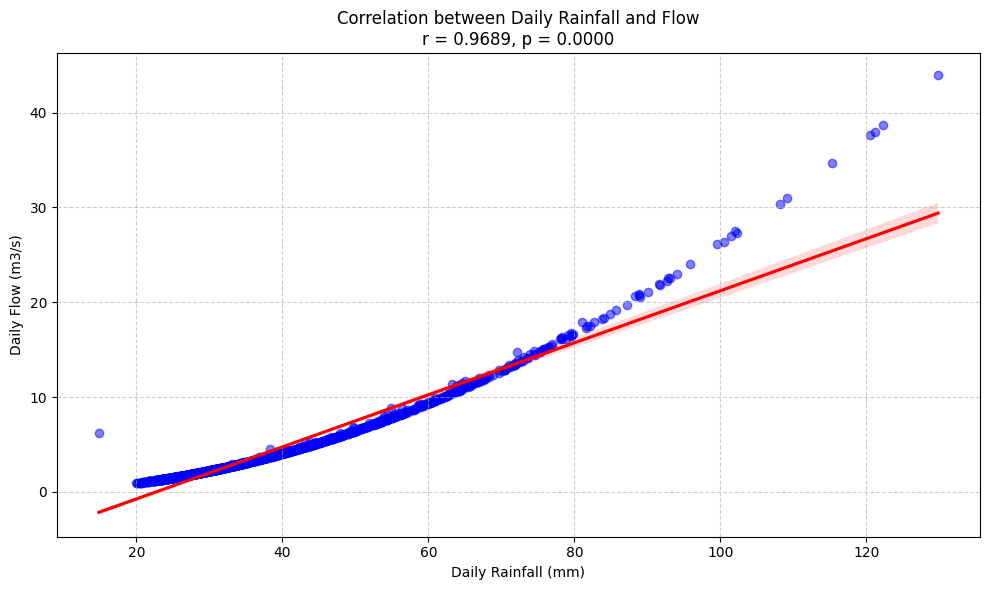

In [15]:
import seaborn as sns
import scipy.stats as stats

# Calculate Pearson Correlation Coefficient and p-value
correlation, p_value = stats.pearsonr(df_daily['Rain_mm'], df_daily['Flow_m3s'])

# Print statistics to console
print(f'Pearson Correlation Coefficient: {correlation:.4f}')
print(f'P-value: {p_value:.4f}')

# Create the visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=df_daily, x='Rain_mm', y='Flow_m3s',
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'}, ci=95)

# Set labels and title
plt.xlabel('Daily Rainfall (mm)')
plt.ylabel('Daily Flow (m3/s)')
plt.title(f'Correlation between Daily Rainfall and Flow\nr = {correlation:.4f}, p = {p_value:.4f}')

# Display the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Trend Analysis (Mann-Kendall Test)

Applied to:
* Daily rainfall
* Daily flow

Outputs:
* Trend direction (increasing/decreasing/no trend)
* p-value (significance)
* Z-statistic
* Sen’s slope (rate of change)

### Mann-Kendall Test (Daily Rainfall Data)



In [16]:
#Install the pymannkendall library to enable statistical trend testing.
!pip install pymannkendall

In [17]:
import pandas as pd
import numpy as np
import pymannkendall as mk

# Perform Mann-Kendall Trend Test on daily rainfall
# The result object (Mann_Kendall_Test) contains attributes: trend, h, p, z, s, var_s, slope
daily_mk_result = mk.original_test(df_daily['Rain_mm'])

# Print the results in a readable format
print('Mann-Kendall Trend Test Results for Daily Rainfall:')
print(f'Trend: {daily_mk_result.trend}')
print(f'Hypothesis (h): {daily_mk_result.h}')
print(f'P-value: {daily_mk_result.p:.4f}')
print(f"Sen's Slope: {daily_mk_result.slope:.4f}")
print(f'S: {daily_mk_result.s}')
print(f'Var(s): {daily_mk_result.var_s:.2f}')
print(f'Z: {daily_mk_result.z:.2f}')

Mann-Kendall Trend Test Results for Daily Rainfall:
Trend: decreasing
Hypothesis (h): True
P-value: 0.0000
Sen's Slope: -0.0025
S: -133945.0
Var(s): 628223961.67
Z: -5.34


## Sen’s Slope Visualisation

* Converts time to numeric index
* Computes Sen’s slope and intercept
* Plots:
  * Original flow time series
  * Trend line (Sen’s slope)

Helps visualise long-term change in flow

### Plot Rainfall with the Sen's (s) slope line (Daily Data)



Mann-Kendall Test Results for Daily Flow:
  Trend: decreasing
  H0 (null hypothesis rejected): True
  p-value: 0.0000
  Z-statistic: -5.34
  Sen's Slope: -0.0025
  Intercept: 36.3149


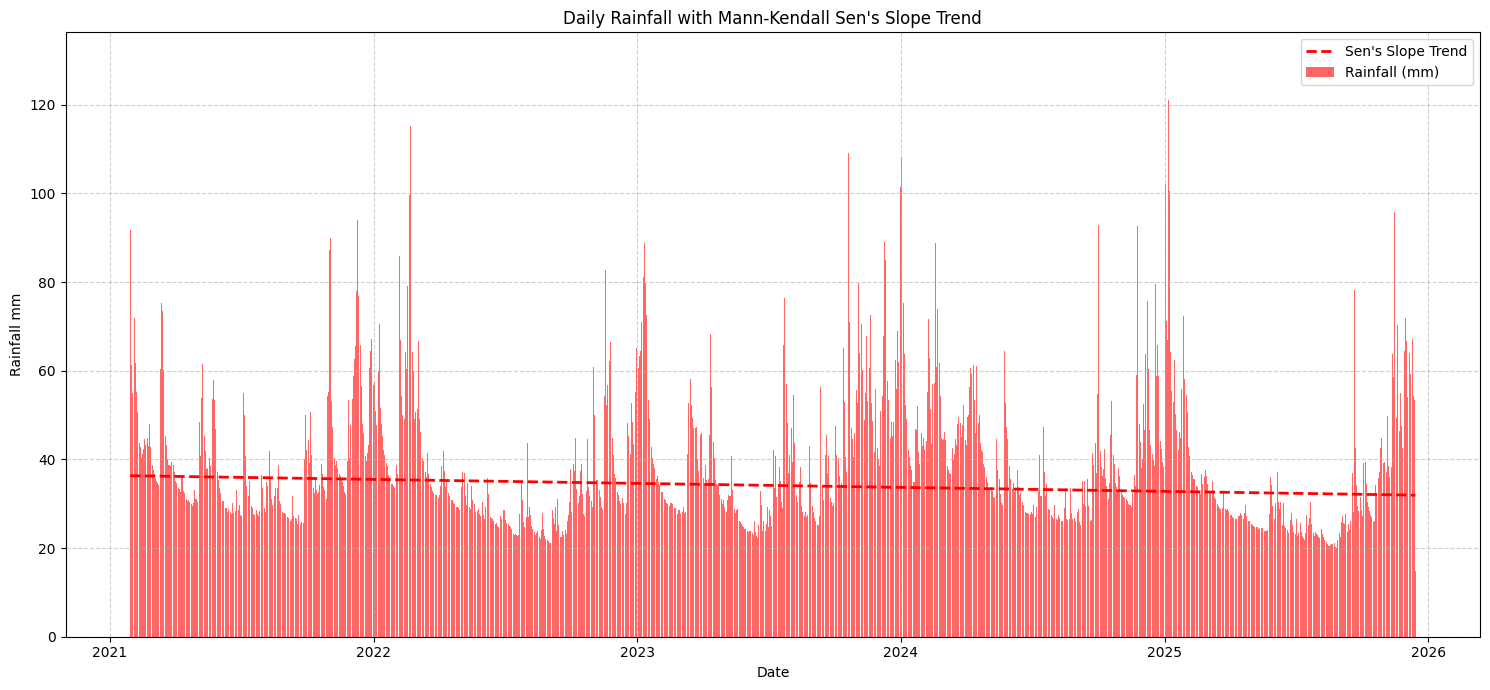

In [18]:
# Use the cleaned daily data
rain_series = df_daily['Rain_mm']

# Create a numeric time array (0 to N-1) for the regression calculation
time_indices = np.arange(len(rain_series))

# Perform the Mann-Kendall test and calculate Sen's slope
daily_mk_result = mk.original_test(rain_series)

# Extract relevant results
sen_slope = daily_mk_result.slope
intercept = daily_mk_result.intercept

print(f"Mann-Kendall Test Results for Daily Flow:")
print(f"  Trend: {daily_mk_result.trend}")
print(f"  H0 (null hypothesis rejected): {daily_mk_result.h}")
print(f"  p-value: {daily_mk_result.p:.4f}")
print(f"  Z-statistic: {daily_mk_result.z:.2f}")
print(f"  Sen's Slope: {sen_slope:.4f}")
print(f"  Intercept: {intercept:.4f}")

# Generate the trend line using Sen's slope and numeric time indices
trend_line = sen_slope * time_indices + intercept

# Create the visualization
plt.figure(figsize=(15, 7))

# Plot the original Rainfall data using the index (Dates)
#plt.plot(df_daily.index, rain_series, label='Daily Rainfall', color='blue', alpha=0.7)
# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
plt.bar(df_daily.index, df_daily['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=0.8)

# Plot the Sen's slope trend line
# We plot this against the index to align with the flow data
plt.plot(df_daily.index, trend_line, color='red', linestyle='--', linewidth=2, label="Sen's Slope Trend")

# Add plot
plt.title('Daily Rainfall with Mann-Kendall Sen\'s Slope Trend')

plt.xlabel('Date')
plt.ylabel('Rainfall mm')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Mann-Kendall Test (Daily Flow Data)



In [19]:
# Perform Mann-Kendall Trend Test on daily flow
# The result object (Mann_Kendall_Test) contains attributes: trend, h, p, z, s, var_s, slope
daily_mk_result = mk.original_test(df_daily['Flow_m3s'])

# Print the results in a readable format
print('Mann-Kendall Trend Test Results for Daily Flow:')
print(f'Trend: {daily_mk_result.trend}')
print(f'Hypothesis (h): {daily_mk_result.h}')
print(f'P-value: {daily_mk_result.p:.4f}')
print(f"Sen's Slope: {daily_mk_result.slope:.4f}")
print(f'S: {daily_mk_result.s}')
print(f'Var(s): {daily_mk_result.var_s:.3f}')
print(f'Z: {daily_mk_result.z:.3f}')

Mann-Kendall Trend Test Results for Daily Flow:
Trend: decreasing
Hypothesis (h): True
P-value: 0.0000
Sen's Slope: -0.0004
S: -130330.0
Var(s): 628223999.333
Z: -5.200


## Sen’s Slope Visualisation

* Converts time to numeric index
* Computes Sen’s slope and intercept
* Plots:
  * Original flow time series
  * Trend line (Sen’s slope)

Helps visualise long-term change in flow

### Plot Flow with the Sen's (s) slope line (Daily Data)



Mann-Kendall Test Results for Daily Flow:
  Trend: decreasing
  H0 (null hypothesis rejected): True
  p-value: 0.0000
  Z-statistic: -5.20
  Sen's Slope: -0.000
  Intercept: 3.264


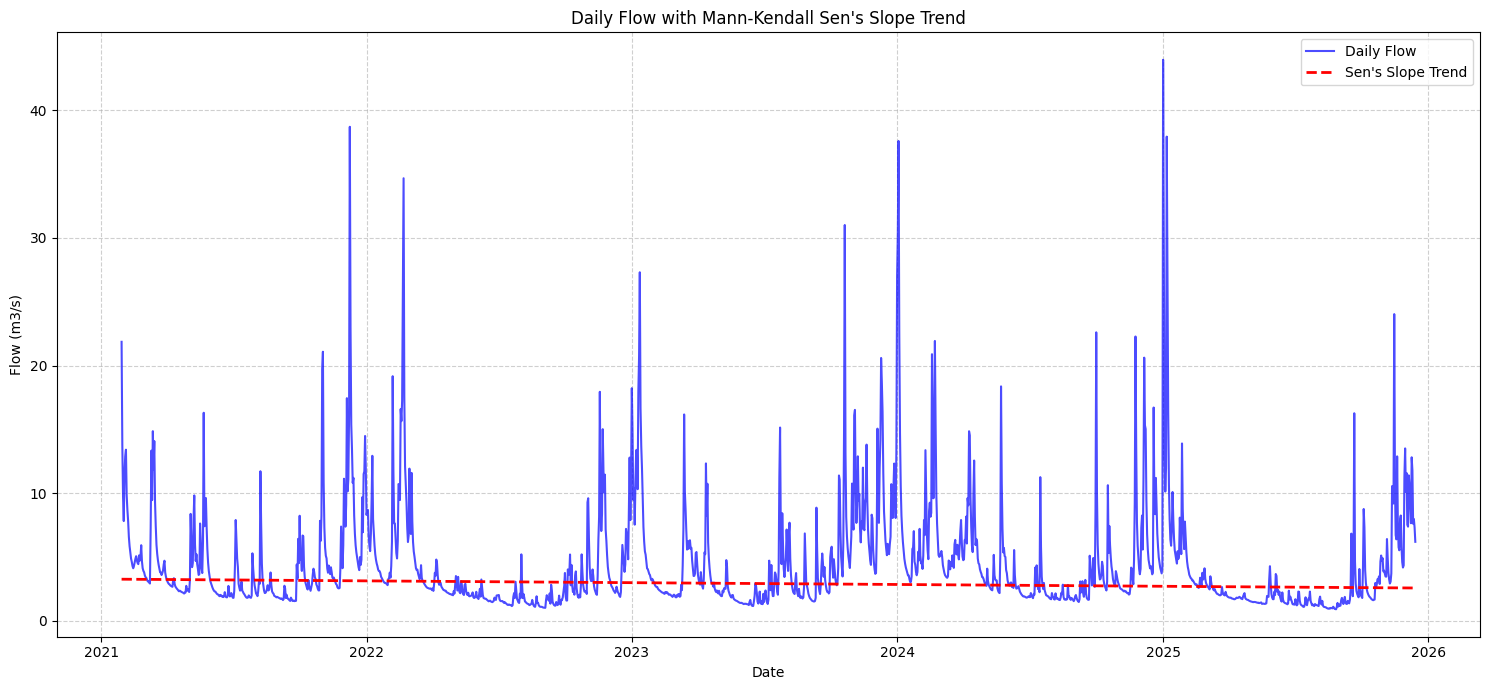

In [20]:
# Use the cleaned daily data
flow_series = df_daily['Flow_m3s']

# Create a numeric time array (0 to N-1) for the regression calculation
time_indices = np.arange(len(flow_series))

# Perform the Mann-Kendall test and calculate Sen's slope
daily_mk_result = mk.original_test(flow_series)

# Extract relevant results
sen_slope = daily_mk_result.slope
intercept = daily_mk_result.intercept

print(f"Mann-Kendall Test Results for Daily Flow:")
print(f"  Trend: {daily_mk_result.trend}")
print(f"  H0 (null hypothesis rejected): {daily_mk_result.h}")
print(f"  p-value: {daily_mk_result.p:.4f}")
print(f"  Z-statistic: {daily_mk_result.z:.2f}")
print(f"  Sen's Slope: {sen_slope:.3f}")
print(f"  Intercept: {intercept:.3f}")

# Generate the trend line using Sen's slope and numeric time indices
trend_line = sen_slope * time_indices + intercept

# Create the visualization
plt.figure(figsize=(15, 7))

# Plot the original Flow data using the index (Dates)
plt.plot(df_daily.index, flow_series, label='Daily Flow', color='blue', alpha=0.7)

# Plot the Sen's slope trend line
# We plot this against the index to align with the flow data
plt.plot(df_daily.index, trend_line, color='red', linestyle='--', linewidth=2, label="Sen's Slope Trend")

# Add plot
plt.title('Daily Flow with Mann-Kendall Sen\'s Slope Trend')

plt.xlabel('Date')
plt.ylabel('Flow (m3/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

This code snippet performs a statistical analysis and visualization of the relationship between daily rainfall (Rain_mm) and daily flow (Flow_m3s) data, whereby:

* **Calculate Pearson Correlation Coefficient and p-value:** It uses scipy.stats.pearsonr to compute the Pearson correlation coefficient (r) and the associated p-value between the 'Rain_mm' and 'Flow_m3s' columns in your df_daily DataFrame. The correlation coefficient measures the linear relationship between the two variables, and the p-value indicates the statistical significance of this correlation.

* **Create Scatter Plot with Regression Line:** It generates a scatter plot using seaborn.regplot to visualize the relationship. A regression line is fitted to this data, showing the overall trend. The ci=95 argument adds a 95% confidence interval around this regression line.



# **Time-Series Analysis (Statistical Tests) - Augmented Dickey-Fuller (ADF) Test**




### **Introduction to Augmented Dickey-Fuller (ADF) Test**

The **Augmented Dickey-Fuller (ADF) test** is a statistical test used to check whether a **time-series is stationary**, meaning its statistical properties (like mean and variance) stay constant over time.


#### What the ADF Test Does:

* **Null hypothesis (H₀):** The series is non-stationary (has a unit root).
* **Alternative hypothesis (H₁):** The series is stationary.


#### What is the Unit Root:

A unit root refers to a characteristic of a time-series that makes it **non-stationary**.

In simple terms:

* A unit root means that the time-series has a persistent, random trend, without a clear long-term trend. It doesn’t revert to a mean, and its variance can increase over time.

#### **3.1.1 Mathematically:**

A basic time-series model might be written as:

$$
y_t = \rho y_{t-1} + \epsilon_t
$$

Where:

* $y_t$ is the current value,
* $y_{t-1}$ is the previous value,
* $\epsilon_t$ is a random error (white noise),
* $\rho$ is a coefficient.

If $\rho = 1$, the process has a **unit root**.



## **Augmented Dickey-Fuller (ADF) Test**

The Augmented Dickey-Fuller (ADF) test checks whether a unit root is present.

* If a unit root is **present** → the series is **non-stationary**.
* If a unit root is **not present** → the series is **stationary**, meaning its statistical properties (like mean and variance) are stable over time.

Augmented Dickey-Fuller (ADF) test uses both p-values and critical values to help determine whether to reject the null hypothesis. Here's a breakdown of both:

**P-values**

* **Meaning:** The p-value represents the probability of observing the obtained test statistic (or a more extreme value) if the null hypothesis were true (i.e.the unit root is present in the time-series). In simpler terms, it tells you how likely it is that the data is non-stationary (unit root present).

* **Interpretation:** A small p-value (typically less than 0.05) suggests strong evidence against the null hypothesis. This means you would reject the null hypothesis and conclude that the time-series is likely stationary.

**Critical values**

* **Meaning:** Critical values are thresholds that depend on the significance level (e.g., 0.05, 0.01) and the sample size. They define the boundaries of the rejection region.

* **Interpretation:** If the ADF test statistic is less than the critical value (for a left-tailed test like the ADF test), you reject the null hypothesis. If the test statistic is greater than the critical value, you fail to reject the null hypothesis.


---

**Critical values are typically provided at different significance levels:**

* 1%: The most stringent level, rejecting the null hypothesis only if there's very strong evidence against it.

* 5%: A common significance level, providing a good balance between Type I and Type II errors.

* 10%: A less stringent level, more likely to reject the null hypothesis.


---


**Relationship between p-values and critical values**

Both p-values and critical values are used to make decisions about the null hypothesis, but they provide slightly different perspectives.

If the p-value is less than the significance level, the test statistic will be more extreme than the critical value.

You can use either the p-value or the critical value approach to reach a conclusion, but it's good practice to consider both.




### **3.2.1 Interpreting the Results:**

* **ADF Statistic:** A calculated value from the test.
* **Critical Values (1%, 5%, 10%):** Thresholds for rejecting the null hypothesis.
* **p-value:** Probability of observing the data if H₀ is true.

➡️ **If the ADF statistic is less than the critical value** (and/or the **p-value < 0.05**):
→ Reject H₀ → **The series is stationary**.

➡️ **If the ADF statistic is greater than the critical value** (and/or the **p-value > 0.05**):
→ Fail to reject H₀ → **The series is non-stationary**.



---

### Summary:

| **Result**                                | **Conclusion**                     |
| ----------------------------------------- | ---------------------------------- |
| ADF statistic < critical value / p < 0.05 | Reject H₀ → Stationary             |
| ADF statistic > critical value / p > 0.05 | Fail to reject H₀ → Non-stationary |



##**Perform the Augmented Dickey-Fuller (ADF) Test**

The next section of code performs the **Augmented Dickey-Fuller (ADF) test** to assess whether a time-series is stationary (i.e. has constant mean and variance over time).

Overall, the code:

* Runs the ADF test on your lake level time series.

* Builds a results table with metrics, values, and interpretations.

* Applies green/red highlighting for easy visual interpretation:

  * Green = stationary (reject H₀)

  * Red = non-stationary (fail to reject H₀)

### Steps in codel explained:

1. The code **Runs the ADF test** on the input `timeseries` for flow data using:

   * `autolag='AIC'`: Automatically selects the best lag length based on the **Akaike Information Criterion (AIC)**.
   * `maxlag=12`: Limits the lag selection to a maximum of 12 lags.
3. **Extracts test results**:

   * Test Statistic
   * p-value
   * Number of lags used
   * Number of observations
   * Critical values at 1%, 5%, and 10% significance levels
4. **Interprets the p-value**:

   * If p-value < 0.05, the series is likely **stationary** (reject the null hypothesis).
   * If p-value ≥ 0.05, the series is likely **non-stationary** (fail to reject the null hypothesis).

### Note on AIC:

**AIC** stands for **Akaike Information Criterion**. It is a statistical measure used to compare different models and select the best one.

The AIC estimates the prediction error for a statistical model relative to other statistical models trained on the same data.

**AIC** balances model fit and complexity.

* **Lower AIC** = better model.
* In this test, it helps choose the best number of lags automatically.


Let us run the code and perform the ADF test on the lake level data and interpret the results to check if the dataset is stationary.

In [21]:
# Define a function to test for stationarity in a time-series
from statsmodels.tsa.stattools import adfuller # # Import Augmented Dickey-Fuller (ADF) test from statsmodels

# Use the daily flow data
#timeseries = df_daily['Flow_m3s']

# Use the daily rainfall data
timeseries = df_daily['Rain_mm']


# Define a function to test for stationarity in a time-series
def adf_test_summary(timeseries, cutoff=0.05): # Parameters timeseries: flow data to test, cutoff: Significance level for p-value (default = 0.05).

    # Run the ADF test on the time-series
    adf_result = adfuller(timeseries, autolag='AIC', maxlag=12)  # autolag='AIC' → chooses lag length automatically using AIC, maxlag=12 → maximum number of lags to test

    # Extract components of the ADF output
    test_statistic = adf_result[0]   # ADF test statistic
    p_value = adf_result[1]          # p-value
    lags_used = adf_result[2]        # Number of lags used in regression
    n_obs = adf_result[3]            # Number of observations after lags removed
    crit_values = adf_result[4]      # Critical values at 1%, 5%, and 10% levels

    # Build results table
    adf_df = pd.DataFrame({
        "Metric": [
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Observations Used",
            "Critical Value (1%)",
            "Critical Value (5%)",
            "Critical Value (10%)"
        ],
        "Value": [
            round(test_statistic, 4),
            round(p_value, 4),
            lags_used,
            n_obs,
            round(crit_values['1%'], 4),
            round(crit_values['5%'], 4),
            round(crit_values['10%'], 4)
        ],
        "Interpretation": [
            "Compare with critical values: lower → more likely stationary.",
            f"p-value = {p_value:.4f} → {'Reject' if p_value < cutoff else 'Fail to reject'} H₀ → Series is {'likely stationary' if p_value < cutoff else 'likely non-stationary'}.",
            "Number of lagged terms used in regression.",
            "Valid data points after removing lags.",
            f"If test statistic < {crit_values['1%']:.4f} → significant at 1% level.",
            f"If test statistic < {crit_values['5%']:.4f} → significant at 5% level.",
            f"If test statistic < {crit_values['10%']:.4f} → significant at 10% level."
        ]
    })

    # Function to apply conditional highlighting to the results table
    def highlight_row(row):
        # Highlight p-value
        if row['Metric'] == 'p-value':
            return ['background-color: green' if row['Value'] < cutoff else 'background-color: salmon'] * len(row)
        # Highlight test statistic relative to 1% critical value
        if row['Metric'] == 'Test Statistic':
            return ['background-color: green' if row['Value'] < crit_values['1%'] else 'background-color: salmon'] * len(row)
        # Highlight critical values based on comparison with test statistic
        if "Critical Value" in row['Metric']:
            return ['background-color: green' if test_statistic < row['Value'] else 'background-color: salmon'] * len(row)
        return [''] * len(row) # No highlighting for other rows

   # Return a styled DataFrame with highlighting
    return adf_df.style.apply(highlight_row, axis=1)

# Create summary results table:
adf_test_summary(timeseries, cutoff=0.05)

,Metric,Value,Interpretation
0,Test Statistic,-5.572400,Compare with critical values: lower → more likely stationary.
1,p-value,0.000000,p-value = 0.0000 → Reject H₀ → Series is likely stationary.
2,#Lags Used,12.000000,Number of lagged terms used in regression.
3,Observations Used,1768.000000,Valid data points after removing lags.
4,Critical Value (1%),-3.434100,If test statistic < -3.4341 → significant at 1% level.
5,Critical Value (5%),-2.863200,If test statistic < -2.8632 → significant at 5% level.
6,Critical Value (10%),-2.567600,If test statistic < -2.5676 → significant at 10% level.


Based on the ADF test results for daily rainfall:

* Test Statistic (-5.5724): This value is significantly lower than all critical values (-3.4341 at 1%, -2.8632 at 5%, and -2.5676 at 10%).
* p-value (0.0000): This is much smaller than the typical significance level of 0.05.

Both of these indicators lead to the same conclusion: We reject the null hypothesis (H₀). This means that the daily rainfall time series is likely stationary.

### **3.3.1 Interpretation of the Augmented Dickey-Fuller Test**

| Metric                   | Value    | Interpretation                                                              |
| :----------------------- | :------- | :-------------------------------------------------------------------------- |
| **Test Statistic**       | -5.5724  | Compare with critical values: lower → more likely stationary.            |
| **p-value**              | 0.0000   | < 0.05 → **Reject H₀** → The series is **likely stationary**.        |
| **#Lags Used**           | 12.0000  | The test used 12 lagged terms in the regression.                            |
| **Observations Used**    | 1768.0000| Number of valid data points used after accounting for lags.                   |
| **Critical Value (1%)**  | -3.4341  | Your test statistic is **below** this → Significant at 1% level.           |
| **Critical Value (5%)**  | -2.8632  | Still **below** → Significant at 5% level.                               |
| **Critical Value (10%)** | -2.5676  | Still **below** → Significant at 10% level.                             |

Why does the Mann-Kendall test suggest a decreasing trend in teh data and Sens slope is negative but the ADF test suggests the data is stationary
That's a great question, and it highlights a crucial difference between what the Mann-Kendall and Augmented Dickey-Fuller (ADF) tests are designed to detect:

* Mann-Kendall Test and Sen's Slope (Trend Detection):

  * The Mann-Kendall test is a non-parametric test used to identify monotonic trends (consistently increasing or decreasing patterns) in time series data. It doesn't assume any particular distribution for the data.
  * Sen's Slope quantifies the magnitude and direction of this trend.
  * When Mann-Kendall shows a 'decreasing' trend and Sen's Slope is negative, it means that, over the observation period, the values in the time series (whether it's rainfall or flow) are generally getting smaller.

* Augmented Dickey-Fuller (ADF) Test (Stationarity Detection):

  * The ADF test, on the other hand, is designed to test for the presence of a unit root. A unit root is a characteristic that makes a time series non-stationary (meaning its statistical properties like mean, variance, and autocorrelation change over time, often implying a 'stochastic' or 'random walk' like trend).

  * If the ADF test indicates 'stationarity' (by rejecting the null hypothesis of a unit root), it means the series' statistical properties are stable, or it is stationary around a deterministic trend.

Why the seemingly contradictory results?

A time series can have a deterministic trend (like a straight line decreasing over time) and still be considered stationary by the ADF test. Here's why:

* Mann-Kendall will detect this deterministic decreasing trend.
* The ADF test primarily looks for stochastic trends (unit roots). If the series has a stable variance and returns to a mean (even if that mean is slowly decreasing over time due to a deterministic trend), the ADF test might conclude it's stationary around that trend. It implies that if you were to remove the deterministic trend, the residuals would be stationary.

In essence, the Mann-Kendall test tells you if there's a trend, and in which direction, while the ADF test tells you if the series' underlying stochastic process is stable (i.e., it doesn't have a unit root driving persistent, unpredictable shifts in its level).

So, it's possible for your data to be generally decreasing over time (as indicated by Mann-Kendall) but still possess stable statistical properties when evaluated for unit roots (as indicated by ADF).